# 08. Classification Models

**Aim:** Implement Decision Tree, Random Forest, and SVM on image features.

## Theory

Decision Trees split data using feature-based rules, Random Forest improves tree-based learning by combining many trees through bagging, and Support Vector Machines separate classes using maximum-margin decision boundaries and kernel transformations. Comparing multiple classifiers helps identify which method works best for the available feature representation.

In [1]:
import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFile
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    silhouette_score,
)

ImageFile.LOAD_TRUNCATED_IMAGES = True
warnings.filterwarnings('ignore')
os.environ.setdefault('MPLCONFIGDIR', os.path.abspath('../logs/.mplconfig'))
os.makedirs(os.environ['MPLCONFIGDIR'], exist_ok=True)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

TRAIN_DIR = Path('../data/PlantDoc-Dataset-master/train/')
TEST_DIR = Path('../data/PlantDoc-Dataset-master/test/')
MANIFEST_PATH = Path('../data/dataset_manifest.csv')
CLEAN_MANIFEST_PATH = Path('../data/dataset_manifest_clean.csv')
FEATURES_PATH = Path('../data/image_features.csv')

def scan_split(split_dir: Path, split_name: str) -> pd.DataFrame:
    records = []
    if not split_dir.exists():
        return pd.DataFrame(columns=['image_path', 'class_name', 'split'])
    for class_dir in sorted([p for p in split_dir.iterdir() if p.is_dir()]):
        for image_path in sorted(class_dir.rglob('*')):
            if image_path.is_file():
                records.append({
                    'image_path': str(image_path.as_posix()),
                    'class_name': class_dir.name,
                    'split': split_name,
                })
    return pd.DataFrame(records)


def ensure_manifest(prefer_clean: bool = True) -> pd.DataFrame:
    target = CLEAN_MANIFEST_PATH if prefer_clean and CLEAN_MANIFEST_PATH.exists() else MANIFEST_PATH
    if target.exists():
        return pd.read_csv(target)

    train_df = scan_split(TRAIN_DIR, 'train')
    test_df = scan_split(TEST_DIR, 'test')
    full_df = pd.concat([train_df, test_df], ignore_index=True)
    full_df['class_name'] = full_df['class_name'].astype(str).str.strip()
    full_df = full_df.drop_duplicates(subset=['image_path']).reset_index(drop=True)
    return full_df


def validate_image(image_path: str):
    path = Path(image_path)
    if not path.exists():
        return False, 'missing'
    try:
        with Image.open(path) as img:
            img.verify()
        return True, 'ok'
    except Exception:
        return False, 'corrupt'


def load_rgb_image(image_path: str, size=(224, 224)):
    with Image.open(image_path) as img:
        rgb = img.convert('RGB').resize(size)
        return np.array(rgb)


def extract_rgb_features(image_array: np.ndarray) -> dict:
    channels = image_array.reshape(-1, 3)
    return {
        'mean_r': float(channels[:, 0].mean()),
        'mean_g': float(channels[:, 1].mean()),
        'mean_b': float(channels[:, 2].mean()),
        'std_r': float(channels[:, 0].std()),
        'std_g': float(channels[:, 1].std()),
        'std_b': float(channels[:, 2].std()),
    }


def ensure_features() -> pd.DataFrame:
    if FEATURES_PATH.exists():
        return pd.read_csv(FEATURES_PATH)

    manifest_df = ensure_manifest(prefer_clean=True).copy()
    quality_records = []
    for image_path in manifest_df['image_path']:
        valid, status = validate_image(image_path)
        quality_records.append((valid, status))
    manifest_df[['is_valid_image', 'file_status']] = pd.DataFrame(quality_records, index=manifest_df.index)
    manifest_df = manifest_df[manifest_df['is_valid_image']].copy().reset_index(drop=True)

    feature_rows = []
    for row in manifest_df.itertuples(index=False):
        image_array = load_rgb_image(row.image_path)
        feature_rows.append({
            'image_path': row.image_path,
            'class_name': row.class_name,
            'split': row.split,
            **extract_rgb_features(image_array),
        })

    features_df = pd.DataFrame(feature_rows)
    return features_df

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

## Code


Decision Tree classification report:
                            precision    recall  f1-score   support

           Apple Scab Leaf       0.08      0.05      0.06        19
                Apple leaf       0.18      0.17      0.17        18
           Apple rust leaf       0.07      0.06      0.06        18
          Bell_pepper leaf       0.06      0.08      0.07        12
     Bell_pepper leaf spot       0.00      0.00      0.00        14
            Blueberry leaf       0.17      0.09      0.11        23
               Cherry leaf       0.00      0.00      0.00        12
       Corn Gray leaf spot       0.00      0.00      0.00        14
          Corn leaf blight       0.27      0.32      0.29        38
            Corn rust leaf       0.00      0.00      0.00        23
                Peach leaf       0.35      0.36      0.36        22
  Potato leaf early blight       0.00      0.00      0.00        23
   Potato leaf late blight       0.04      0.05      0.04        21
         

,model,accuracy,macro_f1
0,Random Forest,0.172816,0.154320
1,SVM (RBF),0.151456,0.082436
2,Decision Tree,0.106796,0.086273


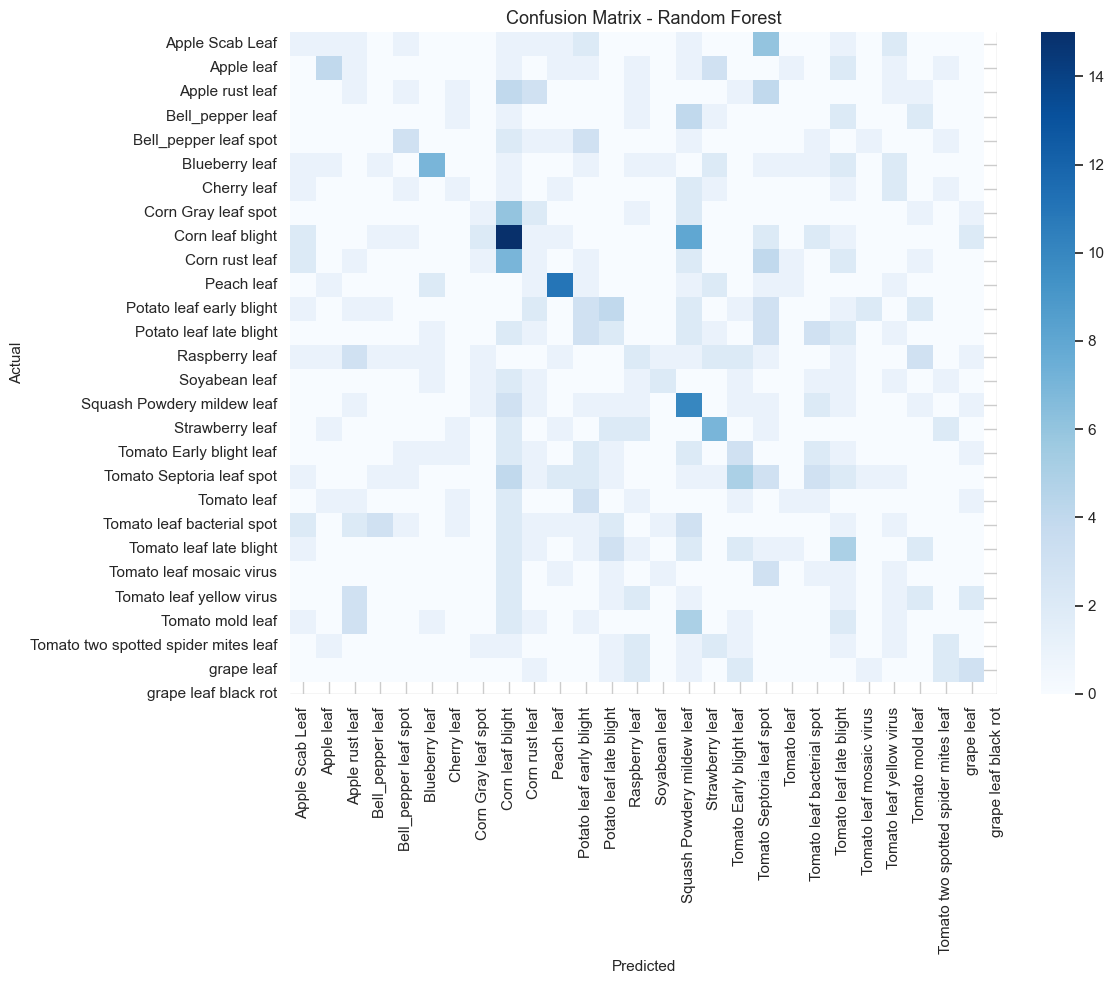

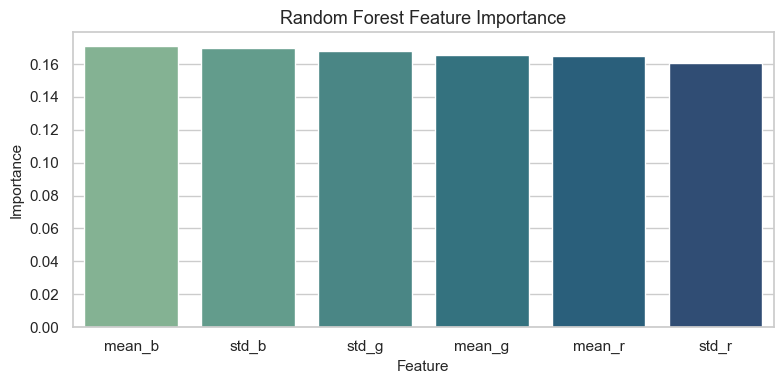

In [2]:
features_df = ensure_features().copy()
feature_cols = ['mean_r', 'mean_g', 'mean_b', 'std_r', 'std_g', 'std_b']
X = features_df[feature_cols]
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(features_df['class_name'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', random_state=42),
}

results = []
fitted_models = {}
for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    results.append({'model': model_name, 'accuracy': accuracy, 'macro_f1': macro_f1})
    fitted_models[model_name] = (model, y_pred)
    print(f'\n{model_name} classification report:')
    # Use labels to handle missing classes in test set
    unique_test_classes = np.unique(y_test)
    test_class_names = label_encoder.classes_[unique_test_classes]
    print(classification_report(y_test, y_pred, labels=unique_test_classes, target_names=test_class_names))

comparison_df = pd.DataFrame(results).sort_values(by='accuracy', ascending=False).reset_index(drop=True)
display(comparison_df)

best_model_name = comparison_df.loc[0, 'model']
best_model, best_pred = fitted_models[best_model_name]
cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

rf_model = fitted_models['Random Forest'][0]
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(8, 4))
sns.barplot(x=importances.index, y=importances.values, palette='crest')
plt.title('Random Forest Feature Importance')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

## Results & Evaluation

In [3]:
print('Model comparison table:')
display(comparison_df)
print(f'Best model: {best_model_name}')

Model comparison table:


,model,accuracy,macro_f1
0,Random Forest,0.172816,0.154320
1,SVM (RBF),0.151456,0.082436
2,Decision Tree,0.106796,0.086273


Best model: Random Forest


## Conclusion

This comparison highlights how different classifiers behave on the same RGB feature set. The resulting accuracy and macro-F1 scores provide a simple benchmark before moving on to more advanced image models such as CNNs or EfficientNet.